In [144]:
library(lme4)
library(ggplot2)
library(dplyr)
library(robustbase)
library(stringr)
library(tidyr)
library(ggpubr)
library(dplyr)
library(rstatix)
library(brms)
library(slider)
library(lubridate)
library(patchwork)
library(purrr)
library(nlme)
library(tidyverse)

In [160]:
# SNPGenie output
product_results <- read.csv("/Users/arimaite/Documents/GitHub/combined_virus_sequencing/RSV/data_analysis/data/RSVB_2024_2025/selective_pressures/results_snpgenie_summary/all_snpgenie_product_results.csv")

codon_results <- read.csv("/Users/arimaite/Documents/GitHub/combined_virus_sequencing/RSV/data_analysis/data/RSVB_2024_2025/selective_pressures/results_snpgenie_summary/all_snpgenie_codon_results.csv")

site_results <- read.csv("/Users/arimaite/Documents/GitHub/combined_virus_sequencing/RSV/data_analysis/data/RSVB_2024_2025/selective_pressures/results_snpgenie_summary/all_snpgenie_site_results.csv")

population_summary_results <- read.csv("/Users/arimaite/Documents/GitHub/combined_virus_sequencing/RSV/data_analysis/data/RSVB_2024_2025/selective_pressures/results_snpgenie_summary/all_snpgenie_population_summary.csv")


# Coverage (V-pipe output)
coverage <- read.csv("/Users/arimaite/Documents/GitHub/combined_virus_sequencing/RSV/data_analysis/data/RSVB_2024_2025/coverage/collected_rsv_coverage_all_2024_2025_EPI_ISL_1653999.tsv")
coverage_initial <- coverage

In [161]:
COVERAGE_THRESHOLD <- 10
FRACTION_COVERED_THRESHOLD <- 0.5

In [162]:
coverage <- coverage %>% group_by(sample) %>%
mutate(count_whole_genome_total_positions = n()) %>%
mutate(is_covered = if_else(coverage >= COVERAGE_THRESHOLD, 1, 0)) %>%
mutate(count_whole_genome_covered_positions = sum(is_covered)) %>%
mutate(fraction_covered_whole_genome = (count_whole_genome_covered_positions / count_whole_genome_total_positions)) %>%
ungroup() 
head(coverage)

pos,coverage,sample,count_whole_genome_total_positions,is_covered,count_whole_genome_covered_positions,fraction_covered_whole_genome
<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>
1,0,A1_05_2024_11_13,15222,0,0,0
2,0,A1_05_2024_11_13,15222,0,0,0
3,0,A1_05_2024_11_13,15222,0,0,0
4,0,A1_05_2024_11_13,15222,0,0,0
5,0,A1_05_2024_11_13,15222,0,0,0
6,0,A1_05_2024_11_13,15222,0,0,0


In [163]:
coverage[((coverage['pos'] >= 57) & (coverage['pos'] <= 476)), "product"]= "NS1"
coverage[((coverage['pos'] >= 584) & (coverage['pos'] <= 958)), "product"]= "NS2"
coverage[((coverage['pos'] >= 1097) & (coverage['pos'] <= 2272)), "product"]= "N"
coverage[((coverage['pos'] >= 2305) & (coverage['pos'] <= 3030)), "product"]= "P"
coverage[((coverage['pos'] >= 3154) & (coverage['pos'] <= 3990)), "product"]= "M"
coverage[((coverage['pos'] >= 4259) & (coverage['pos'] <= 4456)), "product"]= "SH"
coverage[((coverage['pos'] >= 4646) & (coverage['pos'] <= 5578)), "product"]= "G"
coverage[((coverage['pos'] >= 5676) & (coverage['pos'] <= 7400)), "product"]= "F"
coverage[((coverage['pos'] >= 7627) & (coverage['pos'] <= 8214)), "product"]= "M2-1"
# M2-1 and M2-2 overlap. Need to keep overlapping positions twice, otherwise they all get assigned to M2-2.
coverage[((coverage['pos'] >= 8180) & (coverage['pos'] <= 8452)), "product"]= "M2-2"
coverage[((coverage['pos'] >= 8518) & (coverage['pos'] <= 15018)), "product"]= "L"

# extract overlapping rows (currently labeled M2-2)
overlap <- coverage %>%
  filter(pos >= 8180 & pos <= 8214) %>%
  mutate(product = "M2-1")
# Name noncoding part of the genome
coverage[is.na(coverage$product), 'product' ] <- 'noncoding'

# bind back to original
coverage <- bind_rows(coverage, overlap)

In [164]:
coverage_fractioned <- coverage %>%
group_by(sample, product) %>% 
mutate(count_total_positions = n()) %>%
filter(coverage >= COVERAGE_THRESHOLD) %>%
mutate(count_covered_positions = n()) %>%
mutate(mean_positional_coverage = mean(coverage)) %>%
mutate(fraction_covered = (count_covered_positions / count_total_positions)) %>%
select(-c("pos", "coverage")) %>%
distinct(.keep_all = TRUE)

head(coverage_fractioned)
dim(coverage_fractioned)

sample,count_whole_genome_total_positions,is_covered,count_whole_genome_covered_positions,fraction_covered_whole_genome,product,count_total_positions,count_covered_positions,mean_positional_coverage,fraction_covered
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>
A1_05_2024_12_03,15222,1,1431,0.09400867,NS2,375,263,3195.32700,0.7013333
A1_05_2024_12_03,15222,1,1431,0.09400867,noncoding,1505,163,2075.03067,0.1083056
A1_05_2024_12_03,15222,1,1431,0.09400867,N,1176,1005,520.39303,0.8545918
A1_05_2024_12_11,15222,1,323,0.02121929,G,933,323,79.44582,0.3461951
A1_05_2025_01_13,15222,1,2318,0.15227960,NS1,420,378,101.41270,0.9000000
A1_05_2025_01_13,15222,1,2318,0.15227960,P,726,383,2118.87990,0.5275482


[1] 1287   10

In [165]:
coverage_whole_genome <- coverage_initial %>%
group_by(sample) %>%
mutate(count_total_positions = n())%>%
filter(coverage >= COVERAGE_THRESHOLD) %>%
mutate(count_covered_positions = n()) %>%
mutate(mean_positional_whole_genome_coverage = sum(coverage/ count_covered_positions)) %>%
mutate(fraction_covered = count_covered_positions /count_total_positions) %>%
ungroup() %>%
rename(site=pos) %>%
select(-c("coverage"))
head(coverage_whole_genome)

head(site_results)




site_coverage_merged <- left_join(site_results, coverage_whole_genome, by = c("sample", "site")) %>%
filter(coverage >= COVERAGE_THRESHOLD) %>%
filter(fraction_covered >= FRACTION_COVERED_THRESHOLD) %>%

group_by(sample) %>%
mutate(mean_whole_genome_pi = sum(pi) / count_covered_positions) %>%
ungroup() %>%

distinct(sample, mean_whole_genome_pi, fraction_covered, mean_positional_whole_genome_coverage)


site_coverage_merged$reference <- "EPI_ISL_1653999"

write_csv(x = site_coverage_merged, file = "../../../RSV/data_analysis/data/RSVB_2024_2025/selective_pressures/results_snpgenie_processed/RSVB_site_nuc_diversity_whole_genome.csv")
head(site_coverage_merged)



site,sample,count_total_positions,count_covered_positions,mean_positional_whole_genome_coverage,fraction_covered
<int>,<chr>,<int>,<int>,<dbl>,<dbl>
696,A1_05_2024_12_03,15222,1431,1189.096,0.09400867
697,A1_05_2024_12_03,15222,1431,1189.096,0.09400867
698,A1_05_2024_12_03,15222,1431,1189.096,0.09400867
699,A1_05_2024_12_03,15222,1431,1189.096,0.09400867
700,A1_05_2024_12_03,15222,1431,1189.096,0.09400867
701,A1_05_2024_12_03,15222,1431,1189.096,0.09400867


,file,product,site,ref_nt,maj_nt,position_in_codon,overlapping_ORFs,codon_start_site,codon,pi,gdiv,class_vs_ref,class,coverage,A,C,G,T,sample,reference
,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1357,A,G,3,0,1355,GGA,0.000000000,0.000000000,Synonymous,NONREF_NONPOLY,538,0,0.00000,538,0.00000,A1_05_2024_12_03,EPI_ISL_1653999
2,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1385,G,A,1,0,1385,GTA,0.000000000,0.000000000,Nonsynonymous,NONREF_NONPOLY,542,542,0.00000,0,0.00000,A1_05_2024_12_03,EPI_ISL_1653999
3,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1429,C,T,3,0,1427,TTC,0.007518661,0.007511574,Synonymous,Synonymous,1061,0,3.99997,0,1057.00003,A1_05_2024_12_03,EPI_ISL_1653999
4,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1577,C,T,1,0,1577,CTG,0.000000000,0.000000000,Synonymous,NONREF_NONPOLY,530,0,0.00000,0,530.00000,A1_05_2024_12_03,EPI_ISL_1653999
5,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1768,G,G,3,0,1766,GTG,0.058251507,0.058175560,Synonymous,Synonymous,767,0,0.00000,744,23.00003,A1_05_2024_12_03,EPI_ISL_1653999
6,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1771,C,C,3,0,1769,CAC,0.055793313,0.055720571,Synonymous,Synonymous,767,0,745.00014,0,21.99986,A1_05_2024_12_03,EPI_ISL_1653999


sample,mean_whole_genome_pi,fraction_covered,mean_positional_whole_genome_coverage,reference
<chr>,<dbl>,<dbl>,<dbl>,<chr>
A1_05_2025_02_26,0.0004456905,0.5326501,19676.8525,EPI_ISL_1653999
A2_15_2025_02_27,0.0013328306,0.6754697,16781.2680,EPI_ISL_1653999
A2_16_2025_01_01,0.0024494116,0.7600841,8405.6792,EPI_ISL_1653999
A3_16_2024_12_14,0.0018457652,0.6566154,465.8389,EPI_ISL_1653999
A3_25_2025_01_09,0.0006893290,0.5132046,3849.3383,EPI_ISL_1653999
B1_05_2025_02_01,0.0021221388,0.5669426,1223.8316,EPI_ISL_1653999


In [166]:
site_coverage_merged <- left_join(site_results, coverage_fractioned, by = c("sample", "product")) %>%
filter(coverage >= COVERAGE_THRESHOLD) %>%
filter(fraction_covered >= FRACTION_COVERED_THRESHOLD) %>%
filter(fraction_covered_whole_genome >= FRACTION_COVERED_THRESHOLD) %>%

group_by(sample) %>%
mutate(mean_whole_genome_pi = sum(pi)/count_whole_genome_covered_positions) %>%
ungroup() %>%

group_by(sample, product) %>%
mutate(mean_pi = sum(pi)/count_covered_positions) %>% 
distinct(sample, product, mean_pi, fraction_covered, mean_whole_genome_pi, mean_positional_coverage, fraction_covered_whole_genome)

head(site_coverage_merged)
site_coverage_merged$reference <- "EPI_ISL_1653999"

write_csv(x = site_coverage_merged, file = "../../../RSV/data_analysis/data/RSVB_2024_2025/selective_pressures/results_snpgenie_processed/RSVB_site_nuc_diversity.csv")
head(site_coverage_merged)



sample,product,mean_pi,fraction_covered,mean_whole_genome_pi,mean_positional_coverage,fraction_covered_whole_genome
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1_05_2025_02_26,F,0.0002179693,0.5657971,0.0004350903,38550.8238,0.5326501
A1_05_2025_02_26,G,0.0020055236,0.6141479,0.0004350903,33463.5881,0.5326501
A1_05_2025_02_26,L,0.0001811286,0.5486848,0.0004350903,12027.2588,0.5326501
A1_05_2025_02_26,M2-1,0.0001456708,0.8435374,0.0004350903,4108.7560,0.5326501
A1_05_2025_02_26,N,0.0007208324,0.6215986,0.0004350903,5474.0328,0.5326501
A1_05_2025_02_26,NS1,0.0014437271,0.9000000,0.0004350903,838.9286,0.5326501


sample,product,mean_pi,fraction_covered,mean_whole_genome_pi,mean_positional_coverage,fraction_covered_whole_genome,reference
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
A1_05_2025_02_26,F,0.0002179693,0.5657971,0.0004350903,38550.8238,0.5326501,EPI_ISL_1653999
A1_05_2025_02_26,G,0.0020055236,0.6141479,0.0004350903,33463.5881,0.5326501,EPI_ISL_1653999
A1_05_2025_02_26,L,0.0001811286,0.5486848,0.0004350903,12027.2588,0.5326501,EPI_ISL_1653999
A1_05_2025_02_26,M2-1,0.0001456708,0.8435374,0.0004350903,4108.7560,0.5326501,EPI_ISL_1653999
A1_05_2025_02_26,N,0.0007208324,0.6215986,0.0004350903,5474.0328,0.5326501,EPI_ISL_1653999
A1_05_2025_02_26,NS1,0.0014437271,0.9000000,0.0004350903,838.9286,0.5326501,EPI_ISL_1653999


In [167]:
# Coverage - initial (without gene labels added)

coverage_modified <- read.csv("/Users/arimaite/Documents/GitHub/combined_virus_sequencing/RSV/data_analysis/data/RSVB_2024_2025/coverage/collected_rsv_coverage_all_2024_2025_EPI_ISL_1653999.tsv")

codon_coverage_merged <- left_join(codon_results, coverage_modified, by=c("sample", "site" = "pos")) %>% 
rename(site1 = site, coverage1 = coverage)
coverage_modified$pos <- coverage_modified$pos - 1 # substract one (second position in the codon)
codon_coverage_merged <- left_join(codon_coverage_merged, coverage_modified, by=c("sample", "site1" = "pos")) %>%
rename (coverage2 = coverage) 

coverage_modified$pos <- coverage_modified$pos - 1 # substract two (from the initial) (third position in the codon)
codon_coverage_merged <- left_join(codon_coverage_merged, coverage_modified, by=c("sample", "site1" = "pos")) %>% 
rename (coverage3 = coverage) 

codon_coverage_merged$codon_coverage <- rowMeans(codon_coverage_merged[, c("coverage1", "coverage2", "coverage3")], na.rm = TRUE)

# Create location column - location information from the sample ID 
codon_coverage_merged['location'] <- sapply(strsplit(codon_coverage_merged$sample, "_"), `[`, 2)

codon_coverage_merged <- codon_coverage_merged %>%
  separate(sample,
           into = c("id", "loc", "year", "month", "day"),
           sep = "_",
           remove = FALSE) %>%
  unite(date, year, month, day, sep = "_")

# Convert date col to date format
codon_coverage_merged['date'] <- as.Date(codon_coverage_merged$date, format ="%Y_%m_%d")

head(codon_coverage_merged)


,file,product,site1,codon,num_overlap_ORF_nts,N_diffs,S_diffs,N_sites,S_sites,N_sites_ref,⋯,sample,id,loc,date,reference,coverage1,coverage2,coverage3,codon_coverage,location
,<chr>,<chr>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<date>,<chr>,<int>,<int>,<int>,<dbl>,<chr>
1,results_snpgenie/snpgenie_input/A1_05_2024_11_13_snvs_fixed_2.vcf,F,5676,ATG,0,0,0,3.000000,0.0000000,3.000000,⋯,A1_05_2024_11_13,A1,05,2024-11-13,EPI_ISL_1653999,0,0,0,0,05
2,results_snpgenie/snpgenie_input/A1_05_2024_11_13_snvs_fixed_2.vcf,F,5679,GAG,0,0,0,2.666667,0.3333333,2.666667,⋯,A1_05_2024_11_13,A1,05,2024-11-13,EPI_ISL_1653999,0,0,0,0,05
3,results_snpgenie/snpgenie_input/A1_05_2024_11_13_snvs_fixed_2.vcf,F,5682,TTG,0,0,0,2.333333,0.6666667,2.333333,⋯,A1_05_2024_11_13,A1,05,2024-11-13,EPI_ISL_1653999,0,0,0,0,05
4,results_snpgenie/snpgenie_input/A1_05_2024_11_13_snvs_fixed_2.vcf,F,5685,CTG,0,0,0,1.666667,1.3333333,1.666667,⋯,A1_05_2024_11_13,A1,05,2024-11-13,EPI_ISL_1653999,0,0,0,0,05
5,results_snpgenie/snpgenie_input/A1_05_2024_11_13_snvs_fixed_2.vcf,F,5688,ATC,0,0,0,2.333333,0.6666667,2.333333,⋯,A1_05_2024_11_13,A1,05,2024-11-13,EPI_ISL_1653999,0,0,0,0,05
6,results_snpgenie/snpgenie_input/A1_05_2024_11_13_snvs_fixed_2.vcf,F,5691,CAT,0,0,0,2.666667,0.3333333,2.666667,⋯,A1_05_2024_11_13,A1,05,2024-11-13,EPI_ISL_1653999,0,0,0,0,05


In [168]:
# Add information of what fraaction of the product is covered
# Filter out those product for which the coverage is less than 50%
codon_coverage_merged_final <- left_join(codon_coverage_merged,
                                         coverage_fractioned,
                                         by = c("sample", "product")
                                        )
codon_coverage_merged_final <- codon_coverage_merged_final[complete.cases(codon_coverage_merged_final), ]

head(codon_coverage_merged_final)

codon_coverage_merged_final <- codon_coverage_merged_final #%>% 
#filter(fraction_covered >= FRACTION_COVERED_THRESHOLD) %>%
#filter(codon_coverage >= COVERAGE_THRESHOLD) %>%
#filter(fraction_covered_whole_genome >= FRACTION_COVERED_THRESHOLD) # only samples where whole genome coverage > 50%

head(codon_coverage_merged_final)

,file,product,site1,codon,num_overlap_ORF_nts,N_diffs,S_diffs,N_sites,S_sites,N_sites_ref,⋯,codon_coverage,location,count_whole_genome_total_positions,is_covered,count_whole_genome_covered_positions,fraction_covered_whole_genome,count_total_positions,count_covered_positions,mean_positional_coverage,fraction_covered
,<chr>,<chr>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>
12788,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1097,ATG,0,0,0,3.000000,0.0000000,3.000000,⋯,2.3333333,05,15222,1,1431,0.09400867,1176,1005,520.393,0.8545918
12789,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1100,GCT,0,0,0,2.000000,1.0000000,2.000000,⋯,0.6666667,05,15222,1,1431,0.09400867,1176,1005,520.393,0.8545918
12790,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1103,CTT,0,0,0,2.000000,1.0000000,2.000000,⋯,0.0000000,05,15222,1,1431,0.09400867,1176,1005,520.393,0.8545918
12791,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1106,AGC,0,0,0,2.666667,0.3333333,2.666667,⋯,0.0000000,05,15222,1,1431,0.09400867,1176,1005,520.393,0.8545918
12792,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1109,AAA,0,0,0,2.666667,0.3333333,2.666667,⋯,0.0000000,05,15222,1,1431,0.09400867,1176,1005,520.393,0.8545918
12793,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1112,GTC,0,0,0,2.000000,1.0000000,2.000000,⋯,0.0000000,05,15222,1,1431,0.09400867,1176,1005,520.393,0.8545918


,file,product,site1,codon,num_overlap_ORF_nts,N_diffs,S_diffs,N_sites,S_sites,N_sites_ref,⋯,codon_coverage,location,count_whole_genome_total_positions,is_covered,count_whole_genome_covered_positions,fraction_covered_whole_genome,count_total_positions,count_covered_positions,mean_positional_coverage,fraction_covered
,<chr>,<chr>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>
12788,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1097,ATG,0,0,0,3.000000,0.0000000,3.000000,⋯,2.3333333,05,15222,1,1431,0.09400867,1176,1005,520.393,0.8545918
12789,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1100,GCT,0,0,0,2.000000,1.0000000,2.000000,⋯,0.6666667,05,15222,1,1431,0.09400867,1176,1005,520.393,0.8545918
12790,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1103,CTT,0,0,0,2.000000,1.0000000,2.000000,⋯,0.0000000,05,15222,1,1431,0.09400867,1176,1005,520.393,0.8545918
12791,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1106,AGC,0,0,0,2.666667,0.3333333,2.666667,⋯,0.0000000,05,15222,1,1431,0.09400867,1176,1005,520.393,0.8545918
12792,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1109,AAA,0,0,0,2.666667,0.3333333,2.666667,⋯,0.0000000,05,15222,1,1431,0.09400867,1176,1005,520.393,0.8545918
12793,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1112,GTC,0,0,0,2.000000,1.0000000,2.000000,⋯,0.0000000,05,15222,1,1431,0.09400867,1176,1005,520.393,0.8545918


In [169]:
head(codon_coverage_merged_final)
write_csv(x = codon_coverage_merged_final, file = "../../../RSV/data_analysis/data/RSVB_2024_2025/selective_pressures/results_snpgenie_processed/RSVB_codon_coverage_merged.csv")


,file,product,site1,codon,num_overlap_ORF_nts,N_diffs,S_diffs,N_sites,S_sites,N_sites_ref,⋯,codon_coverage,location,count_whole_genome_total_positions,is_covered,count_whole_genome_covered_positions,fraction_covered_whole_genome,count_total_positions,count_covered_positions,mean_positional_coverage,fraction_covered
,<chr>,<chr>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>
12788,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1097,ATG,0,0,0,3.000000,0.0000000,3.000000,⋯,2.3333333,05,15222,1,1431,0.09400867,1176,1005,520.393,0.8545918
12789,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1100,GCT,0,0,0,2.000000,1.0000000,2.000000,⋯,0.6666667,05,15222,1,1431,0.09400867,1176,1005,520.393,0.8545918
12790,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1103,CTT,0,0,0,2.000000,1.0000000,2.000000,⋯,0.0000000,05,15222,1,1431,0.09400867,1176,1005,520.393,0.8545918
12791,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1106,AGC,0,0,0,2.666667,0.3333333,2.666667,⋯,0.0000000,05,15222,1,1431,0.09400867,1176,1005,520.393,0.8545918
12792,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1109,AAA,0,0,0,2.666667,0.3333333,2.666667,⋯,0.0000000,05,15222,1,1431,0.09400867,1176,1005,520.393,0.8545918
12793,results_snpgenie/snpgenie_input/A1_05_2024_12_03_snvs_fixed_2.vcf,N,1112,GTC,0,0,0,2.000000,1.0000000,2.000000,⋯,0.0000000,05,15222,1,1431,0.09400867,1176,1005,520.393,0.8545918


###################################################################################################################



In [ ]:
codon_coverage_merged <- codon_coverage_merged_final

In [36]:
# Read the concentration data
samples <- read.csv("/Users/arimaite/Documents/GitHub/combined_virus_sequencing/RSV/data_analysis/data/samples_tsv/samples_corrected_v2.tsv", 
                    sep = '\t',
                    header = TRUE,
                    colClasses = c(
                      "location" = "character"
                    ))


samples$location <- gsub("10", "Zurich", samples$location)
samples$location <- gsub("16", "Geneva", samples$location)
samples$location <- gsub("15", "Basel", samples$location)
samples$location <- gsub("05", "Lugano", samples$location)
samples$location <- gsub("25", "Laupen", samples$location)
samples$location <- gsub("17", "Chur", samples$location)
samples$date <- as.character(samples$date)

# Have a list of samples that were sequenced for RSV-A (remove only B), and remove non-specific binding:
rsvb_samples <- samples %>% 
  filter(!grepl("A", samples$protocol))
rsvb_samples$date <- as.character(rsvb_samples$date)  # Convert to Date format

# Have a list of samples that were sequenced for RSV-A (remove only B), and remove non-specific binding:
rsva_samples <- samples %>% 
  filter(!grepl("B", samples$protocol))
rsva_samples$date <- as.character(rsva_samples$date)  # Convert to Date format


In [37]:
# Get the concentrations from RSV-A/B assay
rsv_ab_assay <- read.csv(file = '/Users/arimaite/Documents/GitHub/combined_virus_sequencing/RSV/data_analysis/data/concentrations/rsv_ab_assay/viral_loads_imputated_rsvab.csv',
                         check.names = FALSE) %>%
  select(-c(1)) %>%
  select(Date, location, RSV_A, RSV_B, RSV_A_imputed, RSV_B_imputed) %>% # Using loads - these are concentrations normalized by the flow and population size
  rename(RSV_A_smoothed = RSV_A_imputed) %>%
  rename(RSV_B_smoothed = RSV_B_imputed) %>%
  rename(RSV_A_raw = RSV_A) %>%
  rename(RSV_B_raw = RSV_B) %>%
  mutate(Date = as.Date(Date, "%Y-%m-%d")) %>%
  rename(date = Date) 

rsv_ab_assay_raw <- rsv_ab_assay %>% 

  select(date, location, RSV_A_raw, RSV_B_raw) %>%
  rename(RSV_A = RSV_A_raw) %>%
  rename(RSV_B = RSV_B_raw) %>%
  pivot_longer(
    c(RSV_A, RSV_B),
    names_to = "subtype",
    values_to = "subtype_viral_load_raw"
  ) 


rsv_ab_assay_smoothed <- rsv_ab_assay %>% 
  select(date, location, RSV_A_smoothed, RSV_B_smoothed) %>%
  rename(RSV_A = RSV_A_smoothed) %>%
  rename(RSV_B = RSV_B_smoothed) %>%
  pivot_longer(
    c(RSV_A, RSV_B),
    names_to = "subtype",
    values_to = "subtype_viral_load_smoothed"
  )



rsv_ab_assay_raw <- rsv_ab_assay_raw %>% filter(subtype == "RSV_B")
rsv_ab_assay_smoothed <- rsv_ab_assay_smoothed %>% filter(subtype == "RSV_B")

In [38]:
head(rsv_ab_assay)

,date,location,RSV_A_raw,RSV_B_raw,RSV_A_smoothed,RSV_B_smoothed
,<date>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,2024-11-06,Basel,NA,NA,NA,NA
2,2024-11-09,Basel,NA,NA,0,0
3,2024-11-10,Basel,0,0,0,0
4,2024-11-14,Basel,NA,NA,0,0
5,2024-11-17,Basel,0,0,0,0
6,2024-11-18,Basel,0,0,0,0


In [40]:
head(codon_results)


,file,product,site,codon,num_overlap_ORF_nts,N_diffs,S_diffs,N_sites,S_sites,N_sites_ref,S_sites_ref,N_diffs_vs_ref,S_diffs_vs_ref,gdiv,N_gdiv,S_gdiv,sample,reference
,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,results_snpgenie/snpgenie_input/A1_05_2024_11_13_snvs_fixed_2.vcf,F,5676,ATG,0,0,0,3.000000,0.0000000,3.000000,0.0000000,0,0,0,*,*,A1_05_2024_11_13,EPI_ISL_1653999
2,results_snpgenie/snpgenie_input/A1_05_2024_11_13_snvs_fixed_2.vcf,F,5679,GAG,0,0,0,2.666667,0.3333333,2.666667,0.3333333,0,0,0,*,*,A1_05_2024_11_13,EPI_ISL_1653999
3,results_snpgenie/snpgenie_input/A1_05_2024_11_13_snvs_fixed_2.vcf,F,5682,TTG,0,0,0,2.333333,0.6666667,2.333333,0.6666667,0,0,0,*,*,A1_05_2024_11_13,EPI_ISL_1653999
4,results_snpgenie/snpgenie_input/A1_05_2024_11_13_snvs_fixed_2.vcf,F,5685,CTG,0,0,0,1.666667,1.3333333,1.666667,1.3333333,0,0,0,*,*,A1_05_2024_11_13,EPI_ISL_1653999
5,results_snpgenie/snpgenie_input/A1_05_2024_11_13_snvs_fixed_2.vcf,F,5688,ATC,0,0,0,2.333333,0.6666667,2.333333,0.6666667,0,0,0,*,*,A1_05_2024_11_13,EPI_ISL_1653999
6,results_snpgenie/snpgenie_input/A1_05_2024_11_13_snvs_fixed_2.vcf,F,5691,CAT,0,0,0,2.666667,0.3333333,2.666667,0.3333333,0,0,0,*,*,A1_05_2024_11_13,EPI_ISL_1653999


In [51]:
lookup = c(
    '05'='Lugano',
    '10'='Zurich',
    '15'='Basel',
    '16'='Geneva',
    '17'='Chur',
    '25'='Laupen'
)
codon_results$location <- sapply(strsplit(codon_results$sample, "_"), `[`, 2)
codon_results$date <- sapply(
  strsplit(codon_results$sample, "_"),
  function(x) paste(x[3:5], collapse = "_")
)
codon_results$location <- lookup[codon_results$location]
head(codon_results)

,file,product,site,codon,num_overlap_ORF_nts,N_diffs,S_diffs,N_sites,S_sites,N_sites_ref,S_sites_ref,N_diffs_vs_ref,S_diffs_vs_ref,gdiv,N_gdiv,S_gdiv,sample,reference,location,date
,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,results_snpgenie/snpgenie_input/A1_05_2024_11_13_snvs_fixed_2.vcf,F,5676,ATG,0,0,0,3.000000,0.0000000,3.000000,0.0000000,0,0,0,*,*,A1_05_2024_11_13,EPI_ISL_1653999,Lugano,2024_11_13
2,results_snpgenie/snpgenie_input/A1_05_2024_11_13_snvs_fixed_2.vcf,F,5679,GAG,0,0,0,2.666667,0.3333333,2.666667,0.3333333,0,0,0,*,*,A1_05_2024_11_13,EPI_ISL_1653999,Lugano,2024_11_13
3,results_snpgenie/snpgenie_input/A1_05_2024_11_13_snvs_fixed_2.vcf,F,5682,TTG,0,0,0,2.333333,0.6666667,2.333333,0.6666667,0,0,0,*,*,A1_05_2024_11_13,EPI_ISL_1653999,Lugano,2024_11_13
4,results_snpgenie/snpgenie_input/A1_05_2024_11_13_snvs_fixed_2.vcf,F,5685,CTG,0,0,0,1.666667,1.3333333,1.666667,1.3333333,0,0,0,*,*,A1_05_2024_11_13,EPI_ISL_1653999,Lugano,2024_11_13
5,results_snpgenie/snpgenie_input/A1_05_2024_11_13_snvs_fixed_2.vcf,F,5688,ATC,0,0,0,2.333333,0.6666667,2.333333,0.6666667,0,0,0,*,*,A1_05_2024_11_13,EPI_ISL_1653999,Lugano,2024_11_13
6,results_snpgenie/snpgenie_input/A1_05_2024_11_13_snvs_fixed_2.vcf,F,5691,CAT,0,0,0,2.666667,0.3333333,2.666667,0.3333333,0,0,0,*,*,A1_05_2024_11_13,EPI_ISL_1653999,Lugano,2024_11_13


In [54]:
codon_results$date <- as.Date(codon_results$date, format = "%Y_%m_%d")

In [60]:
data_list <- list(rsv_ab_assay_raw, rsv_ab_assay_smoothed, codon_results)

diversity_data <- reduce(data_list, inner_join, by = c("date", "location"))
head(diversity_data)
dim(diversity_data)

date,location,subtype.x,subtype_viral_load_raw,subtype.y,subtype_viral_load_smoothed,file,product,site,codon,⋯,S_sites,N_sites_ref,S_sites_ref,N_diffs_vs_ref,S_diffs_vs_ref,gdiv,N_gdiv,S_gdiv,sample,reference
<date>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<int>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
2024-12-05,Basel,RSV_B,NA,RSV_B,0,results_snpgenie/snpgenie_input/E2_15_2024_12_05_snvs_fixed_2.vcf,F,5676,ATG,⋯,0.0000000,3.000000,0.0000000,0,0,0,*,*,E2_15_2024_12_05,EPI_ISL_1653999
2024-12-05,Basel,RSV_B,NA,RSV_B,0,results_snpgenie/snpgenie_input/E2_15_2024_12_05_snvs_fixed_2.vcf,F,5679,GAG,⋯,0.3333333,2.666667,0.3333333,0,0,0,*,*,E2_15_2024_12_05,EPI_ISL_1653999
2024-12-05,Basel,RSV_B,NA,RSV_B,0,results_snpgenie/snpgenie_input/E2_15_2024_12_05_snvs_fixed_2.vcf,F,5682,TTG,⋯,0.6666667,2.333333,0.6666667,0,0,0,*,*,E2_15_2024_12_05,EPI_ISL_1653999
2024-12-05,Basel,RSV_B,NA,RSV_B,0,results_snpgenie/snpgenie_input/E2_15_2024_12_05_snvs_fixed_2.vcf,F,5685,CTG,⋯,1.3333333,1.666667,1.3333333,0,0,0,*,*,E2_15_2024_12_05,EPI_ISL_1653999
2024-12-05,Basel,RSV_B,NA,RSV_B,0,results_snpgenie/snpgenie_input/E2_15_2024_12_05_snvs_fixed_2.vcf,F,5688,ATC,⋯,0.6666667,2.333333,0.6666667,0,0,0,*,*,E2_15_2024_12_05,EPI_ISL_1653999
2024-12-05,Basel,RSV_B,NA,RSV_B,0,results_snpgenie/snpgenie_input/E2_15_2024_12_05_snvs_fixed_2.vcf,F,5691,CAT,⋯,0.3333333,2.666667,0.3333333,0,0,0,*,*,E2_15_2024_12_05,EPI_ISL_1653999


[1] 1242264      24

In [61]:
# piS: The mean number of pairwise synonymous differences per synonymous site in this product.
diversity_data['piS'] = diversity_data['S_diffs']/diversity_data['S_sites']

# piN: The mean number of pairwise nonsynonymous differences per nonsynonymous site in this product.
diversity_data['piN'] = diversity_data['N_diffs']/diversity_data['N_sites']

head(diversity_data)

diversity_data <- diversity_data %>%
group_by(
    location, date, product, subtype_viral_load_raw
) %>% 
summarise(mean_piN = mean(piN, na.rm=TRUE),
         mean_piS = mean(piS, na.rm=TRUE)) %>% pivot_longer(cols = c("mean_piS", "mean_piN"), names_to = "piS_piN", values_to = "pi")

head(diversity_data)


date,location,subtype.x,subtype_viral_load_raw,subtype.y,subtype_viral_load_smoothed,file,product,site,codon,⋯,S_sites_ref,N_diffs_vs_ref,S_diffs_vs_ref,gdiv,N_gdiv,S_gdiv,sample,reference,piS,piN
<date>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<int>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
2024-12-05,Basel,RSV_B,NA,RSV_B,0,results_snpgenie/snpgenie_input/E2_15_2024_12_05_snvs_fixed_2.vcf,F,5676,ATG,⋯,0.0000000,0,0,0,*,*,E2_15_2024_12_05,EPI_ISL_1653999,NaN,0
2024-12-05,Basel,RSV_B,NA,RSV_B,0,results_snpgenie/snpgenie_input/E2_15_2024_12_05_snvs_fixed_2.vcf,F,5679,GAG,⋯,0.3333333,0,0,0,*,*,E2_15_2024_12_05,EPI_ISL_1653999,0,0
2024-12-05,Basel,RSV_B,NA,RSV_B,0,results_snpgenie/snpgenie_input/E2_15_2024_12_05_snvs_fixed_2.vcf,F,5682,TTG,⋯,0.6666667,0,0,0,*,*,E2_15_2024_12_05,EPI_ISL_1653999,0,0
2024-12-05,Basel,RSV_B,NA,RSV_B,0,results_snpgenie/snpgenie_input/E2_15_2024_12_05_snvs_fixed_2.vcf,F,5685,CTG,⋯,1.3333333,0,0,0,*,*,E2_15_2024_12_05,EPI_ISL_1653999,0,0
2024-12-05,Basel,RSV_B,NA,RSV_B,0,results_snpgenie/snpgenie_input/E2_15_2024_12_05_snvs_fixed_2.vcf,F,5688,ATC,⋯,0.6666667,0,0,0,*,*,E2_15_2024_12_05,EPI_ISL_1653999,0,0
2024-12-05,Basel,RSV_B,NA,RSV_B,0,results_snpgenie/snpgenie_input/E2_15_2024_12_05_snvs_fixed_2.vcf,F,5691,CAT,⋯,0.3333333,0,0,0,*,*,E2_15_2024_12_05,EPI_ISL_1653999,0,0


`summarise()` has grouped output by 'location', 'date', 'product'. You can
override using the `.groups` argument.


location,date,product,subtype_viral_load_raw,piS_piN,pi
<chr>,<date>,<chr>,<dbl>,<chr>,<dbl>
Basel,2024-12-05,F,NA,mean_piS,0
Basel,2024-12-05,F,NA,mean_piN,0
Basel,2024-12-05,G,NA,mean_piS,0
Basel,2024-12-05,G,NA,mean_piN,0
Basel,2024-12-05,L,NA,mean_piS,0
Basel,2024-12-05,L,NA,mean_piN,0


In [62]:
unique(diversity_data$location)

[1] "Basel"  "Chur"   "Geneva" "Laupen" "Lugano" "Zurich"

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 638 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 638 rows containing missing values or values outside the scale
range (`geom_point()`).”


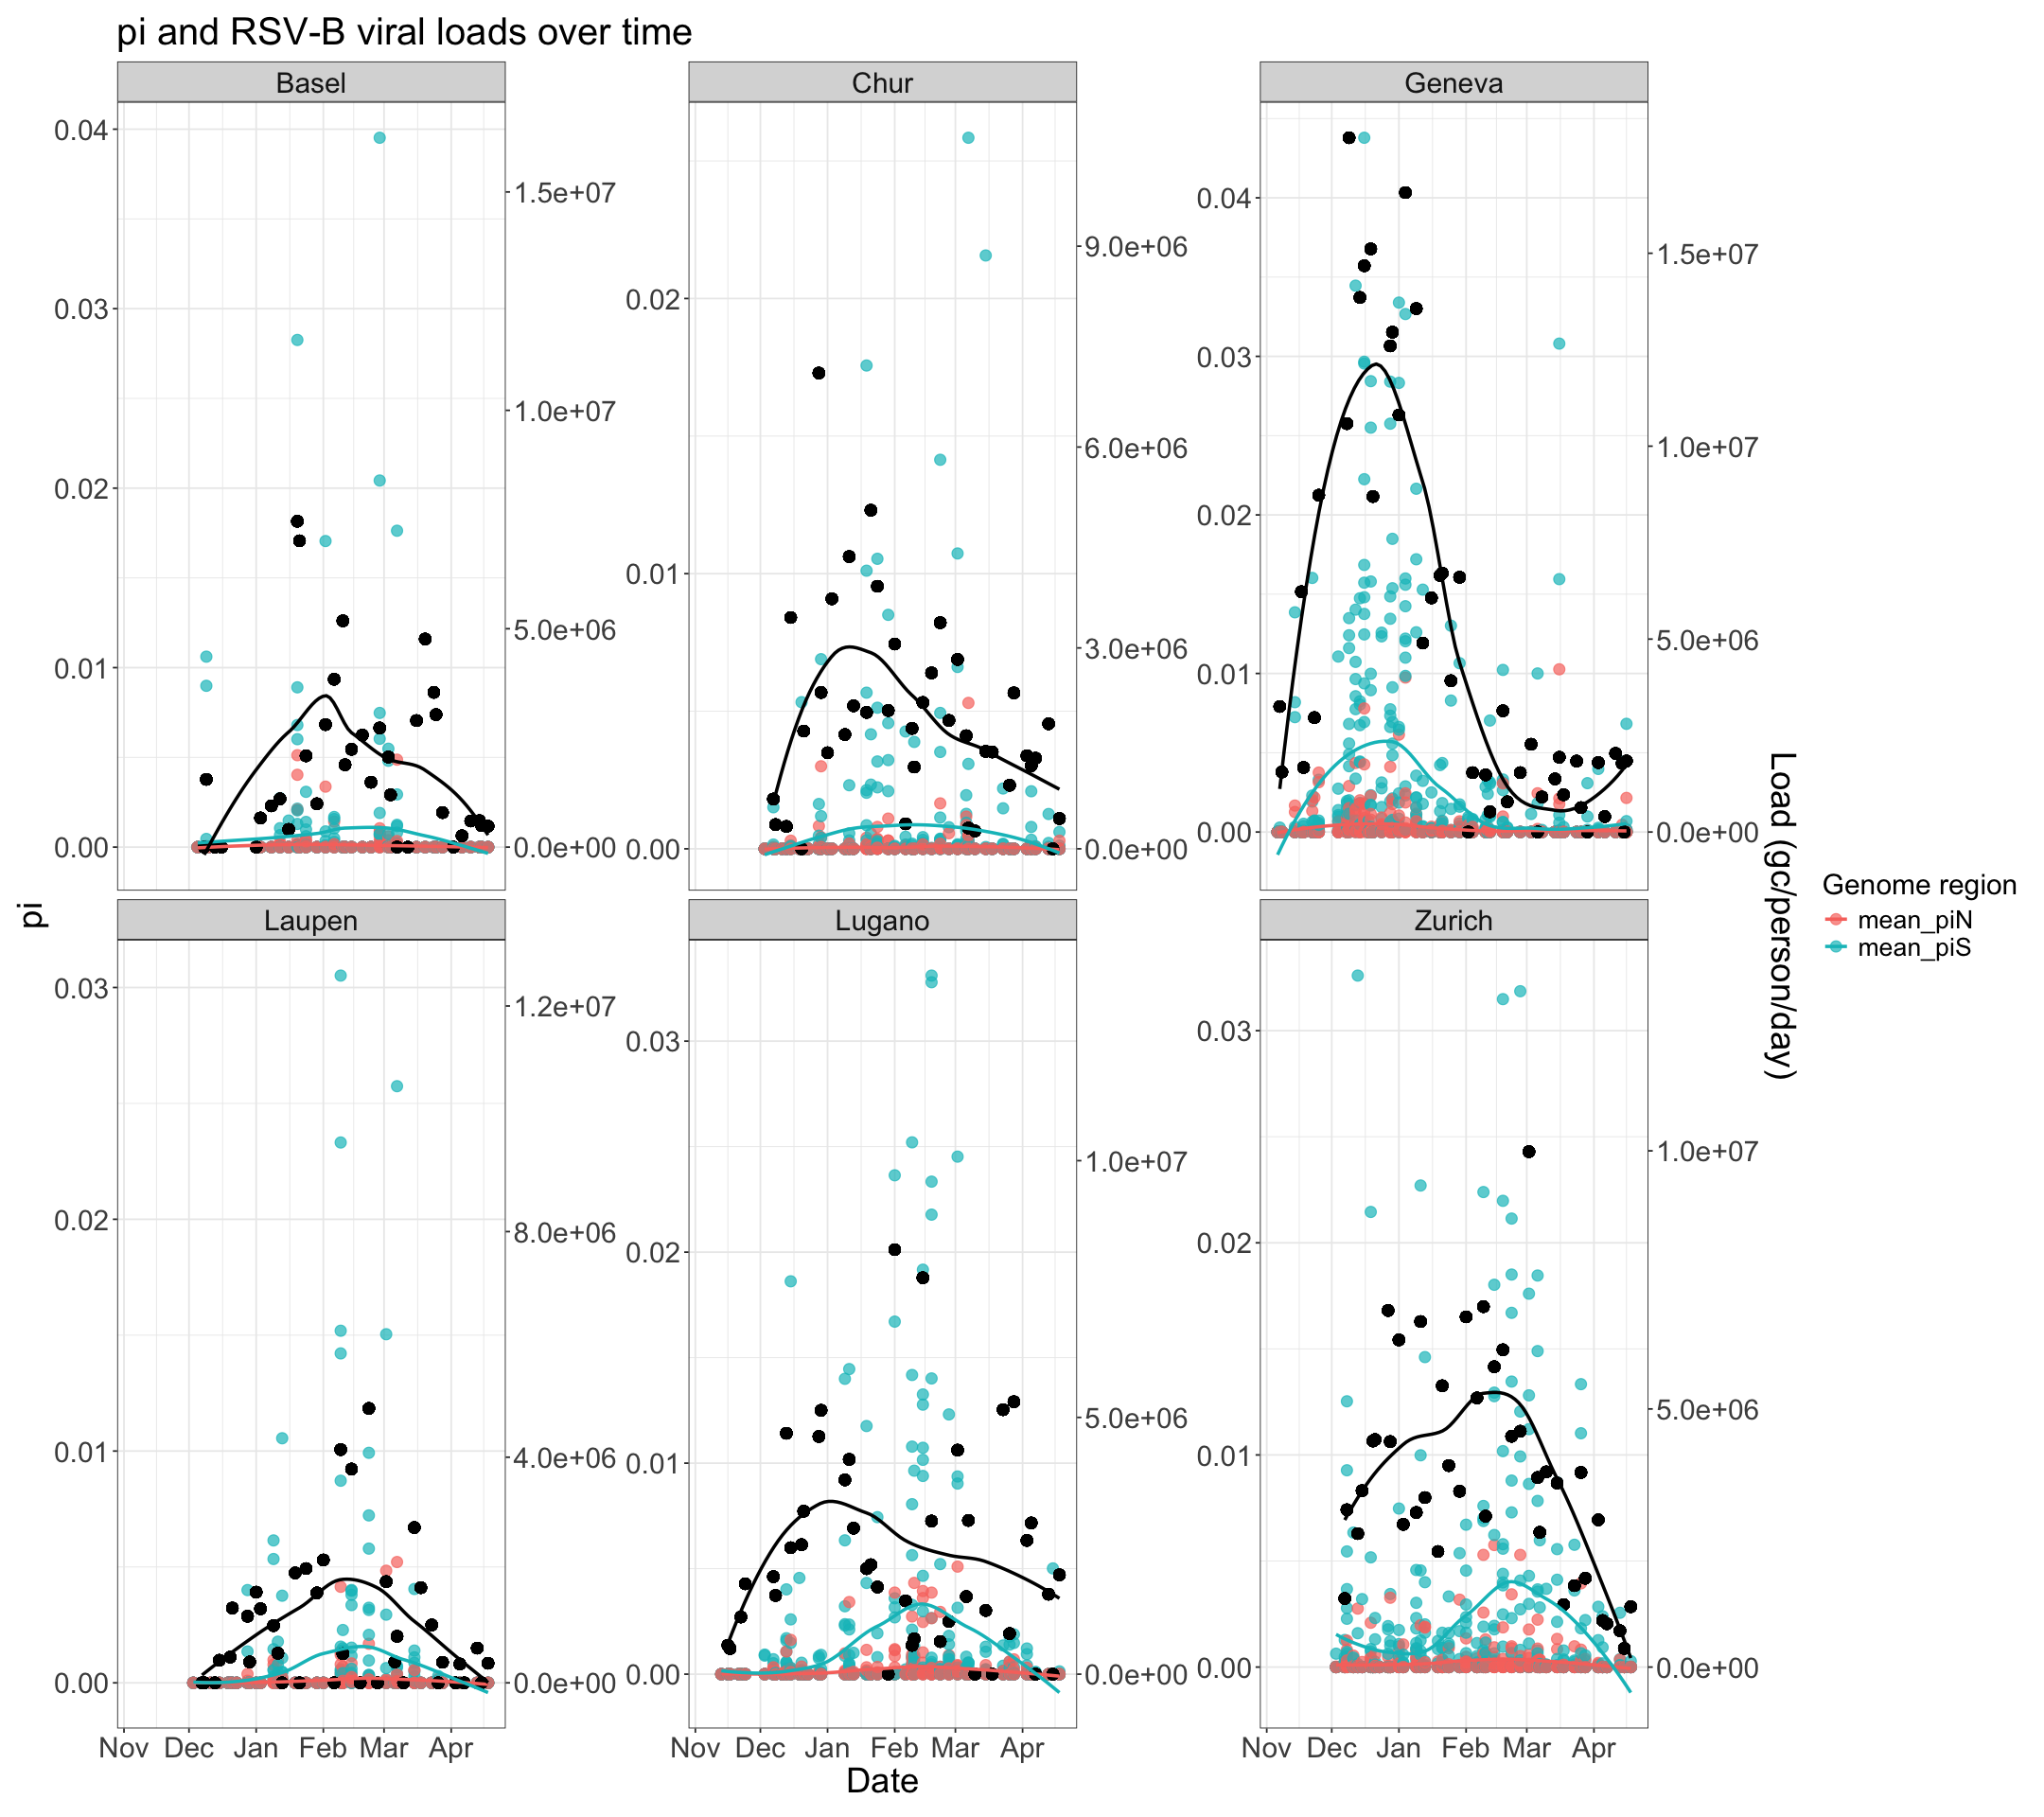

In [64]:
# Viral loads smoothed
options(repr.plot.width = 18, repr.plot.height = 16)

min_points <- 5  # minimum points to fit loess


# RSV-A (identical logic)
df_b <- diversity_data #%>% filter(subtype == "RSV_A")

max_mean_entropy_b <- max(df_b$pi, na.rm = TRUE)
max_rsvb <- max(df_b$subtype_viral_load_raw, na.rm = TRUE)
scale_factor_b <- max_rsvb / max_mean_entropy_b

counts_b <- df_b %>%
  group_by(location, product) %>%
  summarise(n_points = n(), .groups = "drop")

valid_regions_b <- counts_b %>% filter(n_points >= min_points)

p_b <- ggplot(df_b, aes(x = date)) +
  geom_point(aes(y = pi, color = piS_piN), alpha = 0.7, size = 3) +
  geom_point(aes(y = subtype_viral_load_raw / scale_factor_b), color = "black", size = 3) +
  geom_smooth(
    data = df_b %>% semi_join(valid_regions_b, by = c("location", "product")),
    aes(y = pi, color = piS_piN),
    method = "loess",
    #span = 0.3,
    se = FALSE,
    linewidth = 1
  ) +
  geom_smooth(
    aes(y=subtype_viral_load_raw / scale_factor_b),
    method = "loess",
    #span = 0.3,
    se = FALSE,
    linewidth = 1,
    color = "black"
  ) +
  facet_wrap(~ location, scales = "free_y") +
  scale_y_continuous(
    name = "pi",
    sec.axis = sec_axis(~.*scale_factor_b, name = "Load (gc/person/day)")
  ) +
  theme_bw() +
  labs(
    title = "pi and RSV-B viral loads over time",
    x = "Date",
    color = "Genome region"
  ) +
  #scale_color_manual(values = c("F" = "#1f78b4", "G" = "#33a02c", "genome" = "#e31a1c")) + 

  theme(
    text = element_text(size = 20),
    axis.title = element_text(size = 22),
    axis.text = element_text(size = 18),
    strip.text = element_text(size = 18),
    legend.title = element_text(size = 18),
    legend.text = element_text(size = 16)
  )

# Combine both
p_b + plot_layout(ncol =1)


In [67]:
df_a

location,date,product,subtype_viral_load_raw,piS_piN,pi
<chr>,<date>,<chr>,<dbl>,<chr>,<dbl>
Basel,2024-11-06,F,NA,mean_piS,0
Basel,2024-11-06,F,NA,mean_piN,0
Basel,2024-11-06,G,NA,mean_piS,0
Basel,2024-11-06,G,NA,mean_piN,0
Basel,2024-11-06,L,NA,mean_piS,0
Basel,2024-11-06,L,NA,mean_piN,0
Basel,2024-11-06,M,NA,mean_piS,0
Basel,2024-11-06,M,NA,mean_piN,0
Basel,2024-11-06,M2-1,NA,mean_piS,0
